In [1]:
# import numpy for math calculations
import numpy as np

# import pandas for data (csv) manipulation
import pandas as pd

# import gc to collect garbage
import gc

# import matplotlib for plotting
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('fivethirtyeight') 
%matplotlib inline

# import seaborn for more plotting options(built on top of matplotlib)
import seaborn as sns

# import librosa for analysing audio signals : visualize audio, display the spectogram
import librosa
import soundfile as sf

# import librosa for analysing audio signals : visualize audio, display the spectogram
import librosa.display


# import wav for reading and writing wav files
import wave

# import IPython.dispaly for playing audio in Jupter notebook
import IPython.display as ipd

# import os for system operations
import os

# import random for get random values/choices
import random

# import sklearn for machine learning modelling and preprocessing
import sklearn

# importing from sklearn the evaluation metrics for classification
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix

# importing from sklearn model selection 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, learning_curve,StratifiedShuffleSplit


# Import PyTorch libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_model_summary import summary
from torchview import draw_graph
#import torch.nn.functional as F

from pathlib import Path
import torchaudio
print("Libraries imported - ready to use PyTorch", torch.__version__)

# import tqdm to show a smart progress meter
from tqdm.notebook import trange,tqdm

# import warnings to hide the unnessairy warniings
import warnings
warnings.filterwarnings('ignore')

OSError: dlopen(/Users/daniel/anaconda3/lib/python3.11/site-packages/torchaudio/lib/libtorchaudio.so, 0x0006): Symbol not found: __ZN2at8internal15invoke_parallelExxxRKNSt3__18functionIFvxxEEE
  Referenced from: <609B69AF-4C54-382D-B35D-196F185665F8> /Users/daniel/anaconda3/lib/python3.11/site-packages/torchaudio/lib/libtorchaudio.so
  Expected in:     <ACE097DE-AAE9-3CE7-BEE3-D5FF6F8E4FBA> /Users/daniel/anaconda3/lib/libtorch_cpu.dylib

In [53]:
# import random 
# SEED = 42
# def seed_everything(seed=42): 
#     random.seed(seed) 
#     os.environ['PYTHONHASHSEED'] = str(seed) 
#     np.random.seed(seed) 
# seed_everything(SEED)

# I. Project understanding

## 1. Introduction

# II. Data Exploration and Visualization
___

In [3]:
# To get a list of the pathes of all the audio files
data = "/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-master/Audio/"
dataset = pd.read_csv('/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/esc50.csv')
all_files = []
for path, subdirs, files in os.walk(data):
    for name in files:
        all_files.append(os.path.join(path, name))
        
# A dictionary to decode the categories into targets
decoder = {0: 'dog', 14: 'chirping_birds', 36: 'vacuum_cleaner', 19: 'thunderstorm', 30: 'door_wood_knock',34: 'can_opening', 9: 'crow', 22: 'clapping', 48: 'fireworks', 41: 'chainsaw', 47: 'airplane', 31: 'mouse_click', 17: 'pouring_water', 45: 'train', 8: 'sheep', 15: 'water_drops', 46: 'church_bells', 37: 'clock_alarm', 32: 'keyboard_typing', 16: 'wind', 25: 'footsteps', 4: 'frog', 3: 'cow', 27: 'brushing_teeth', 43: 'car_horn', 12: 'crackling_fire', 40: 'helicopter', 29: 'drinking_sipping', 10: 'rain', 7: 'insects', 26: 'laughing', 6: 'hen', 44: 'engine', 23: 'breathing', 20: 'crying_baby', 49: 'hand_saw', 24: 'coughing', 39: 'glass_breaking', 28: 'snoring', 18: 'toilet_flush', 2: 'pig', 35: 'washing_machine', 38: 'clock_tick', 21: 'sneezing', 1: 'rooster', 11: 'sea_waves', 42: 'siren', 5: 'cat', 33: 'door_wood_creaks', 13: 'crickets'}

# A dictionary to encode the categories into targets
encoder = {'dog': 0, 'chirping_birds': 14, 'vacuum_cleaner': 36, 'thunderstorm': 19, 'door_wood_knock': 30, 'can_opening': 34, 'crow': 9, 'clapping': 22, 'fireworks': 48, 'chainsaw': 41, 'airplane': 47, 'mouse_click': 31, 'pouring_water': 17, 'train': 45, 'sheep': 8, 'water_drops': 15, 'church_bells': 46, 'clock_alarm': 37, 'keyboard_typing': 32, 'wind': 16, 'footsteps': 25, 'frog': 4, 'cow': 3, 'brushing_teeth': 27, 'car_horn': 43, 'crackling_fire': 12, 'helicopter': 40, 'drinking_sipping': 29, 'rain': 10, 'insects': 7, 'laughing': 26, 'hen': 6, 'engine': 44, 'breathing': 23, 'crying_baby': 20, 'hand_saw': 49, 'coughing': 24, 'glass_breaking': 39, 'snoring': 28, 'toilet_flush': 18, 'pig': 2, 'washing_machine': 35, 'clock_tick': 38, 'sneezing': 21, 'rooster': 1, 'sea_waves': 11, 'siren': 42, 'cat': 5, 'door_wood_creaks': 33, 'crickets': 13}

In [4]:
plot_files = random.choices(all_files, k = 10)
plot_audios = [librosa.load(plot_files[i]) for i in range(10)]

## A. Exploring the Audio Data

Let's first explore a random audio sample of dog bark `1-100032-A-0.wav` by printing the values of : 
* **Sample rate (sr)** : defines the number of samples per second (or per other unit) taken from a continuous signal to make a discrete or digital signal.
* **Amplitude (y)** : a measure of how high (and low) the wave extends from the x axis

In [5]:
# Importing 1 file
y, sr = librosa.load(data + "1-100032-A-0.wav")

print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample Rate (KHz):', sr, '\n')

# The duration is equal to the number of frames divided by the framerate
print('Duration of the audio file:', np.shape(y)[0]/sr, 'second')

y: [ 0. -0.  0. ...  0.  0.  0.] 

y shape: (110250,) 

Sample Rate (KHz): 22050 

Duration of the audio file: 5.0 second


## B. Distribution of Categories

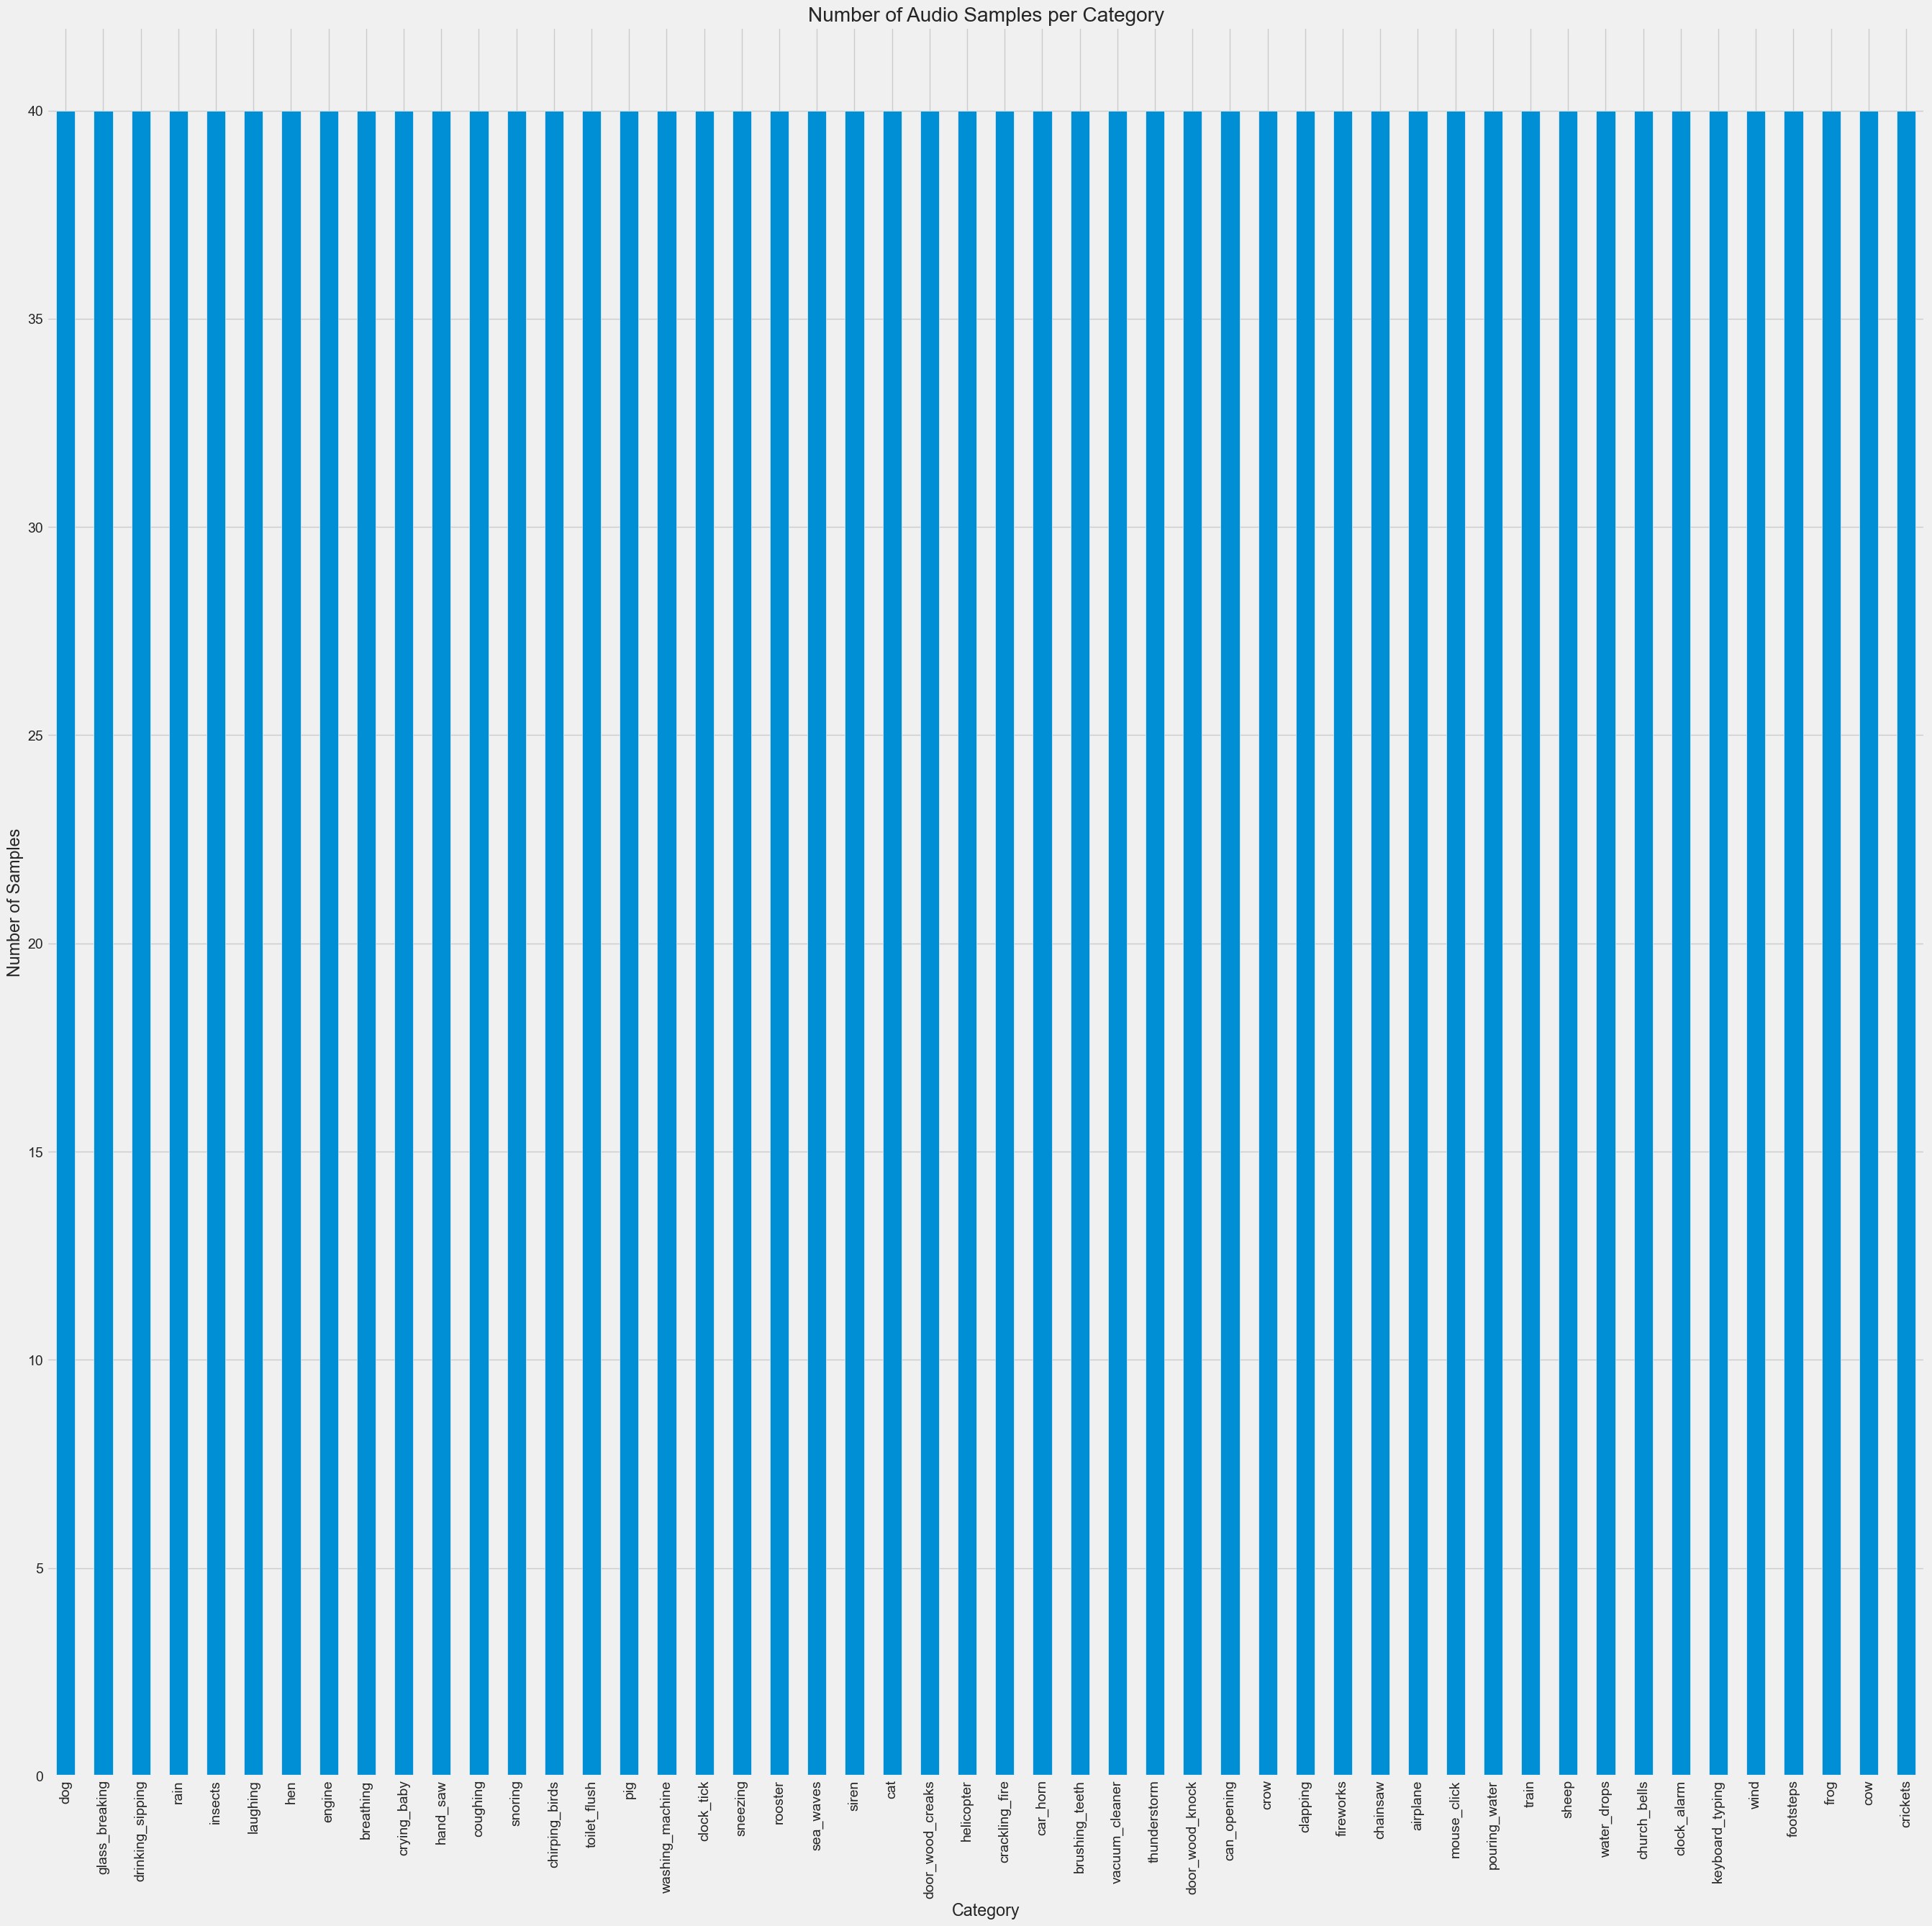

In [57]:
category_group = dataset['category'].value_counts()
plot = category_group.plot(kind='bar', title="Number of Audio Samples per Category", figsize=(30,30))
plot.set_xlabel("Category")
plot.set_ylabel("Number of Samples");

# III. Data Augmentation

In [58]:
path_audio = "/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-master/Audio/"

In [59]:
def add_noise(data):
    noise = np.random.normal(0, 0.1, len(data))
    audio_noisy = data + noise
    return audio_noisy
    
def pitch_shifting(data):
    sr  = 16000
    bins_per_octave = 12
    pitch_pm = 2
    pitch_change =  pitch_pm * 2*(np.random.uniform())   
    data = librosa.effects.pitch_shift(data.astype('float64'),  sr, n_steps=pitch_change, 
                                          bins_per_octave=bins_per_octave)
    return pitch_shifting

def random_shift(data):
    timeshift_fac = 0.2 *2*(np.random.uniform()-0.5)  # up to 20% of length
    start = int(data.shape[0] * timeshift_fac)
    if (start > 0):
        data = np.pad(data,(start,0),mode='constant')[0:data.shape[0]]
    else:
        data = np.pad(data,(0,-start),mode='constant')[0:data.shape[0]]
    return data

def volume_scaling(data):
    sr  = 16000
    dyn_change = np.random.uniform(low=1.5,high=2.5)
    data = data * dyn_change
    return data
    
def time_stretching(data, rate):
    input_length = len(data)
    streching = data.copy()
    streching = librosa.effects.time_stretch(streching, rate=rate)
    
    if len(streching) > input_length:
        streching = streching[:input_length]
    else:
        streching = np.pad(data, (0, max(0, input_length - len(streching))), "constant")
    return streching
    
def audio_augmentation(file, aug):
    directory = 'ESC-50-augmented-data/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    aug = np.array(aug,dtype='float32').reshape(-1,1)
    sf.write(directory+'/'+ file, aug, 16000, 'PCM_24')

In [60]:
def data_aug():
    path_ = np.random.choice(os.listdir(path_audio), size = (2000,), replace= False)
    for k,files in zip(range(len(path_)), path_):
        if files[0] != "5":
            data_, fs = librosa.load(os.path.join(path_audio, files), sr = 16000)
            noise_data = add_noise(data_)
            random_shift_data = random_shift(data_)
            volume_scale_data = volume_scaling(data_)
            time_stretching_data =  time_stretching(data_,rate=1.5)
            aug = [noise_data,time_stretching_data, random_shift_data,volume_scale_data ]
            for j in range(len(aug)):
                filename = (files[0:2]+'generated'+'-'+str(j)+'-'+str(k)+'-'+files[2:])
                audio_augmentation(filename, aug[j])
#data_aug()

In [61]:
all_files = []
dataset['files_path'] = data+dataset['filename']

dataset  = dataset.drop(columns=['esc10','take','src_file','category'])
data_aug = '/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-augmented-data/'
for path, subdirs, files in os.walk(data_aug):
    for name in files:
        fold = int(name[0])
        target = int(name.split('-')[-1].replace('.wav', ''))
        file_path = data_aug + name
        dataset.loc[-1] = [name, fold, target, file_path]
        dataset.index = dataset.index + 1  # shifting index
        dataset = dataset.sort_index()
        all_files.append(os.path.join(path, name))

ValueError: invalid literal for int() with base 10: '.'

# IV. Data Loader
___

### 1. Utitity functions

In [24]:
def visualize_log_mel_spect(mel_spectrogram_db,sample_rate,hop_length=320):
    librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel',hop_length=hop_length)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Log Mel spectrogram')
    plt.tight_layout()
    plt.show()

In [36]:
def compute_log_mel_spect(audio,sample_rate):  # Size of the Fast Fourier Transform (FFT), which will also be used as the window length
    n_fft=1024
    hop_length=514#257matlab
    window_type ='hann'
    mel_bins = 60 # Number of mel bands
    normalized_y = librosa.util.normalize(audio)
    Mel_spectrogram = librosa.feature.melspectrogram(y=normalized_y, sr=sample_rate,hop_length=hop_length, win_length=n_fft, n_mels = mel_bins)
    mel_spectrogram_db = librosa.power_to_db(Mel_spectrogram)
    return  mel_spectrogram_db

In [53]:
audio, sample_rate = librosa.load("/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-master/Audio/1-137-A-32.wav",sr=None)
mel_spectrogram_db = compute_log_mel_spect(audio, sample_rate)
# plt.figure(figsize=(10,10))
# librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='hz')
# plt.colorbar()
print(mel_spectrogram_db.shape)
import scipy
scipy.io.savemat('/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/test.mat', {'matrix_name':mel_spectrogram_db})

#visualize_log_mel_spect(mel_spectrogram_db,22050)

(60, 431)


In [47]:
def compute_log_mel_spectogram(audio,sample_rate):  # Size of the Fast Fourier Transform (FFT), which will also be used as the window length
    n_fft=1024
    hop_length=512
    window_type ='hann'
    mel_bins = 60 # Number of mel bands
    normalized_y = librosa.util.normalize(audio)
    Mel_spectrogram = librosa.feature.melspectrogram(y=normalized_y, sr=sample_rate,hop_length=hop_length, win_length=n_fft, n_mels = mel_bins)
    mel_spectrogram_db = librosa.power_to_db(Mel_spectrogram)
    return  mel_spectrogram_db

source_dst = "/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-augmented-data/" + "1-generated-1-420-32373-A-35" + ".wav"
audio, sample_rate = librosa.load(source_dst) #sr=None <- true sample rate
mel_spectrogram_db = compute_log_mel_spectogram(audio, sample_rate)
delta=librosa.feature.delta(mel_spectrogram_db)
data = np.dstack( (mel_spectrogram_db,delta) ) #print(data.shape)
data_tensor = torch.tensor(data, dtype=torch.float32) #print(data_tensor.shape)
data_tensor =  data_tensor.permute(2, 0, 1) #print(data_tensor.shape)



print(data_tensor.shape)  # torch.Size([2, 60, 216])



import torch
import torchvision.transforms as T
x = data_tensor
# Convert to a 4D tensor, assuming the data represents 1-channel images
x = x.unsqueeze(1)  # [2, 1, 60, 288] - 1 channel added

# Use Resize to resize the "image" to 60x216
resize = T.Resize((60, 216))
x_resized = resize(x)

# Remove the channel dimension if needed
data_tensor = x_resized.squeeze(1)  # Back to [2, 60, 216]

print(data_tensor.shape)  # torch.Size([2, 60, 216])









#Save to local tensor
destination_file = '/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/test.pt'
torch.save(data_tensor, destination_file)

print(data_tensor.shape)









#DEBUG - checks that data is the same, the sum==0 means it has the same data
tmp = torch.load(destination_file)
torch.sum(torch.add(-tmp,data_tensor))
#print(data_tensor.shape)


torch.Size([2, 60, 288])
torch.Size([2, 60, 216])
torch.Size([2, 60, 216])


tensor(0.)

In [50]:


#Save to local tensor
#destination_file = '/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/test.pt'
#torch.save(data_tensor, destination_file)






# 
# 
# data=[]
# 
# for i in tqdm(range(len(dataset))):
#     wave_file=dataset.iat[i,3]
#     audio, sample_rate = librosa.load(wave_file)
#     mel_spectrogram_db=(compute_log_mel_spect(audio,sample_rate))
# 
#     data.append( )
# 
# dataset['data']=data
# (2,60, 216)


torch.Size([2, 60, 216])

### 2. Preparing the training data

In [46]:
# data=[]
# from tqdm.auto import tqdm 
# for i in tqdm(range(len(dataset))):
#     wave_file=dataset.iat[i,3]
#     audio, sample_rate = librosa.load(wave_file)
#     mel_spectrogram_db=(compute_log_mel_spect(audio,sample_rate))
#     delta=librosa.feature.delta(mel_spectrogram_db)
#     data.append( np.dstack( (mel_spectrogram_db,delta) ))
# 
# dataset['data']=data

In [3]:
# Save to CSV
dst = '/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-augmented-data-Tensor/stacked_data.csv'
#dataset.to_csv(dst, index=False)

#dataset.to_pickle(dst)

dataset = pd.read_pickle(dst)

In [48]:
#dataset = []
#dataset = pd.read_csv('/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-augmented-data-Tensor/stacked_data.csv')

In [11]:
from torchvision.transforms import Resize
#import torchaudio.transforms as T

X = dataset.drop(columns=['files_path','fold','filename','target'])
y = dataset.target

In [12]:
# Initialize the StratifiedShuffleSplit object
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Split the data into training and testing sets
for train_index, test_index in sss.split(X, y):
    train_df = dataset.iloc[train_index]
    test_df = dataset.iloc[test_index]

print("Size of the training set : ", train_df.shape )
print("Size of the testing set : ", test_df.shape )

train_df = train_df[['data','target']]
test_df = test_df[['data','target']]

Size of the training set :  (7113, 5)
Size of the testing set :  (1779, 5)


### 3. Data Loader

In [13]:
class escDataset(Dataset):
    def __init__(self,dataset, transformation, device):
        self.dataset = dataset
        self.device = device
        self.transformation = transformation
        self.length=len(self.dataset)

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        spectogram = torch.tensor(self._get_audio_spectogram(index))
        label = self._get_audio_sample_label(index)
        spectogram=spectogram.permute(2, 0, 1)
        resize_transform = Resize((60, 216))
        spectogram = resize_transform(spectogram)
        #spectogram  = spectogram.to(self.device)
        #spectogram  = self.transformation(spectogram)
        return spectogram, label
    def _get_audio_spectogram(self, index):
        y = self.dataset.iloc[index, 0].astype(np.float32)
        return y

    def _get_audio_sample_label(self, index):
        return self.dataset.iloc[index, 1]

In [14]:
class MyReshape(object):
    """Reshape the image array."""
    
    def __init__(self, output_size):
        assert isinstance(output_size, (tuple))

        self.output_size = output_size
    def __call__(self, image):
        return image.reshape(self.output_size)

In [15]:
# build transformation pipelines for data augmentation

train_transforms = transforms.Compose([ MyReshape(output_size=(2,60, 216) ) ])
test_transforms = transforms.Compose([MyReshape(output_size=(2,60, 216))])

In [122]:
batch_size = 50
device='mps'

train_data = escDataset(train_df,train_transforms,device)
test_data = escDataset(test_df,train_transforms,device)

train_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

NameError: name 'escDataset' is not defined

# V. Model Building

In [123]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 5 conv blocks / flatten / linear / softmax
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=24, kernel_size=(6,6), stride=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=24, out_channels=24, kernel_size=(6,6), stride=1),
            nn.BatchNorm2d(24),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=(5,5), stride=(2,2)),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=48, kernel_size=(5,5), stride=(2,2)),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=64, kernel_size=(4,4), stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(4,4), stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.connected_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*43, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, 50),
            nn.Softmax(),
        )

    def forward(self, input_data):
        #input_data = input_data.to(device)
        x = self.conv1(input_data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x= self.connected_layer(x)
        return x

In [124]:
cnn = CNN().to(device)
input_data = torch.randn(64, 2,60,216)

/Users/daniel/anaconda3/lib/python3.11/site-packages/torch/overrides.py:1636: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  result = torch_func_method(public_api, types, args, kwargs)


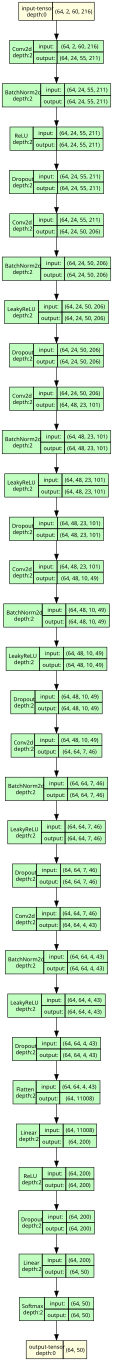

In [125]:
model_graph = draw_graph(cnn,input_data, roll=True)
model_graph.visual_graph

In [126]:
#summary(cnn,(2,60,216))

TypeError: conv2d() received an invalid combination of arguments - got (tuple, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias, tuple of ints stride, tuple of ints padding, tuple of ints dilation, int groups)
      didn't match because some of the arguments have invalid types: (!tuple of (int, int, int)!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, int)
 * (Tensor input, Tensor weight, Tensor bias, tuple of ints stride, str padding, tuple of ints dilation, int groups)
      didn't match because some of the arguments have invalid types: (!tuple of (int, int, int)!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, int)


## A. Training Loop

In [26]:
def train(model, device, train_loader, optimizer, epoch):
    # Set the model to training mode
    model.train()
    train_loss = 0
    print("------------------------------- Epoch:", epoch,"-------------------------------")
    # Process the images in batches
    for batch_idx, (data, target) in enumerate(train_loader):
        # Use the CPU or GPU as appropriate
        # Recall that GPU is optimized for the operations we are dealing with
        data, target = data.to(device), target.to(device)

        # Reset the optimizer
        optimizer.zero_grad()

        # Push the data forward through the model layers
        output = model(data.to(device))

        # Get the loss
        loss = loss_criteria(output, target)

        # Keep a running total
        train_loss += loss.item()

        # Backpropagate
        loss.backward(retain_graph=True)
        optimizer.step()

        # Print metrics so we see some progress
        #print('\tTraining batch {} Loss: {:.6f}'.format(batch_idx + 1, loss.item()))
            
    # return average loss for the epoch
    avg_loss = train_loss / (batch_idx+1)
    print('Training set:\t\tAverage loss: {:.6f}'.format(avg_loss))
    return avg_loss

## B. Testing loop

In [27]:
def test(model, device, test_loader):
    # Switch the model to evaluation mode (so we don't backpropagate or drop)
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        batch_count = 0
        for data, target in test_loader:
            batch_count += 1
            data, target = data.to(device), target.to(device)
            
            # Get the predicted classes for this batch
            output = model(data)
            
            # Calculate the loss for this batch
            test_loss += loss_criteria(output, target).item()
            
            # Calculate the accuracy for this batch
            _, predicted = torch.max(output.data, 1)
            correct += torch.sum(target==predicted).item()

    # Calculate the average loss and total accuracy for this epoch
    avg_loss = test_loss / batch_count
    print('Validation set:\t\tAverage loss: {:.6f},\tAccuracy: {}/{} ({:.0f}%)\n'.format(avg_loss, correct, len(test_loader.dataset),100. * correct / len(test_loader.dataset)))
    
    # return average loss for the epoch
    return avg_loss, (100. * correct / len(test_loader.dataset))

## C. Training & Evaluating the model

In [73]:
def training(model):
    # Use an "Adam" optimizer to adjust weights
    optimizer = optim.Adam(model.parameters(), lr=3e-4)

    # Specify the loss criteria
    loss_criteria = nn.CrossEntropyLoss()

    # Track metrics in these arrays
    epoch_nums = []
    training_loss = []
    validation_loss = []
    test_accs = []
    epochs = 100
    print('Training on', device)
    best_valid_loss = float('inf')
    patience = 5
    patience_counter = 0
    for epoch in tqdm(range(1, epochs + 1)):
        train_loss = train(model, device, train_loader, optimizer, epoch)
        test_loss,test_acc = test(model, device, test_loader)
        if test_loss < best_valid_loss:
            best_valid_loss = test_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
        epoch_nums.append(epoch)
        training_loss.append(train_loss)
        validation_loss.append(test_loss)
        
        test_accs.append(test_acc)
        
        if patience_counter >= patience:
           print(f'Early stopping after {epoch} epochs')
           return test_accs
           break

    return test_accs

In [74]:
# loss_criteria = nn.CrossEntropyLoss()
# training(CNN().to(device))

# V. Evaluation
---

In [49]:
N_SPLIT = 3
# Initialize the StratifiedShuffleSplit object
test_acc_fold = []
sss = StratifiedShuffleSplit(n_splits=N_SPLIT, test_size=0.2, random_state=42)

for fold, (train_index, test_index) in enumerate(sss.split(X, y)):# Split the data into training and testing sets
    print(f'Fold {fold+1}/{N_SPLIT}')

    train_df = dataset.iloc[train_index]
    test_df = dataset.iloc[test_index]

    #print("Size of the training set : ", train_df.shape )
    #print("Size of the testing set : ", test_df.shape )
    
    train_df = train_df[['data','target']]
    test_df = test_df[['data','target']]
    
    batch_size = 50
    device='mps'
    
    train_data = escDataset(train_df,train_transforms,device)
    test_data = escDataset(test_df,train_transforms,device)
    
    train_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
    
    loss_criteria = nn.CrossEntropyLoss()
    test_acc_fold.append(training(CNN().to(device)))
  

Fold 1/3
Size of the training set :  (7113, 5)
Size of the testing set :  (1779, 5)
Training on mps


  0%|          | 0/2 [00:00<?, ?it/s]

------------------------------- Epoch: 1 -------------------------------
Training set:		Average loss: 3.875923
Validation set:		Average loss: 3.849824,	Accuracy: 169/1779 (9%)

------------------------------- Epoch: 2 -------------------------------
Training set:		Average loss: 3.825626
Validation set:		Average loss: 3.815722,	Accuracy: 222/1779 (12%)

Fold 2/3
Size of the training set :  (7113, 5)
Size of the testing set :  (1779, 5)
Training on mps


  0%|          | 0/2 [00:00<?, ?it/s]

------------------------------- Epoch: 1 -------------------------------
Training set:		Average loss: 3.862991
Validation set:		Average loss: 3.831342,	Accuracy: 195/1779 (11%)

------------------------------- Epoch: 2 -------------------------------
Training set:		Average loss: 3.799294
Validation set:		Average loss: 3.786540,	Accuracy: 279/1779 (16%)

Fold 3/3
Size of the training set :  (7113, 5)
Size of the testing set :  (1779, 5)
Training on mps


  0%|          | 0/2 [00:00<?, ?it/s]

------------------------------- Epoch: 1 -------------------------------
Training set:		Average loss: 3.878106
Validation set:		Average loss: 3.858098,	Accuracy: 150/1779 (8%)

------------------------------- Epoch: 2 -------------------------------
Training set:		Average loss: 3.837063
Validation set:		Average loss: 3.812018,	Accuracy: 244/1779 (14%)


In [50]:
test_acc_fold

[[9.499718943226531, 12.478920741989882],
 [10.961214165261383, 15.682967959527824],
 [8.431703204047217, 13.71557054525014]]

Median Accuracy: 13.71557054525014
Average Accuracy: 13.959153082255947


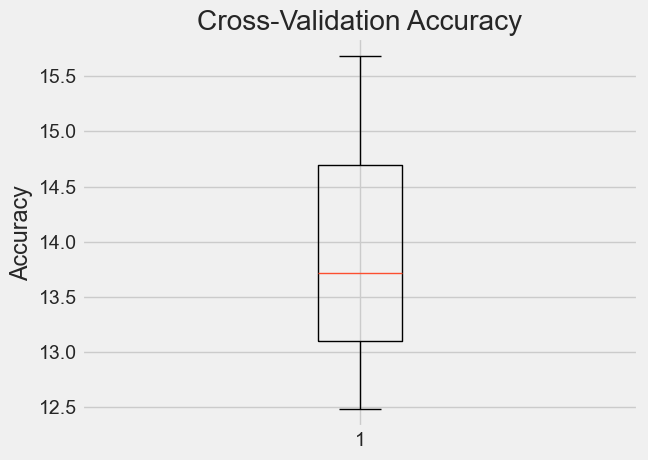

In [72]:
fold_results = np.array(test_acc_fold)
fold_results_final = fold_results[:,-1]
#print(fold_results[:,-1])

# Calculate median, average, and plot boxplot
median_accuracy = np.median(fold_results_final)
average_accuracy = np.mean(fold_results_final)

print(f"Median Accuracy: {median_accuracy}")
print(f"Average Accuracy: {average_accuracy}")

# Plot boxplot of accuracies
plt.boxplot(fold_results_final);plt.title('Cross-Validation Accuracy');plt.ylabel('Accuracy');plt.show()



In [88]:
seed = np.floor(np.random.uniform(size=1)*100)
seed[0]

94.0

In [90]:
torch.Generator()

In [ ]:
np.random.seed()